In [26]:
import matplotlib.pyplot as plt
import random
import time
import math

In [27]:
# function for the analysis of time complexity with plots
def Analyse_Plot(size,theory,actual):
    c = (actual[-1])/(theory[-1]) # matching the last values to get the constant to scale with
    theory_scaled = [c*t for t in theory] # scaled theoretical times

    plt.plot(size,theory_scaled,c='r',label='theoretical')
    plt.plot(size,actual,label='actual')
    plt.legend()
    plt.yscale("log")
    plt.xscale("log")
    plt.show()

#function for generating random list/array:
def generate(n):
    array = [random.randint(-1000,1000) for i in range(n)]
    return array

In [28]:
# max subarray recursion
def mid_cross_max_subarray(A, low, mid, high):
    left_sum = float("-inf")
    total = 0
    max_left = mid

    for i in range(mid, low - 1, -1):
        total += A[i]

        if total > left_sum:
            left_sum = total
            max_left = i

    right_sum = float("-inf")
    total = 0
    max_right = mid + 1

    for j in range(mid + 1, high + 1):
        total += A[j]

        if total > right_sum:
            right_sum = total
            max_right = j

    return (max_left, max_right, left_sum + right_sum)


def max_subarray(A, low, high):
    # Base case
    if low == high:
        return (low, high, A[low])

    mid = (low + high) // 2

    left = max_subarray(A, low, mid)
    right = max_subarray(A, mid + 1, high)
    cross = mid_cross_max_subarray(A, low, mid, high)

    if left[2] >= right[2] and left[2] >= cross[2]:
        return left

    elif right[2] >= left[2] and right[2] >= cross[2]:
        return right

    else:
        return cross

In [29]:
sizes = [10,50,100,500,1000,10000,50000,100000,500000,1000000]
actual = []
for size in sizes:
    array = generate(size)
    start = time.perf_counter()
    max_subarray(array,0,size-1)
    time_taken = time.perf_counter()-start
    actual.append(time_taken) # appending the time taken

# The recurrence relation for the max subarray alogorithm : T(n) = 2T(n/2) + n
# From recursion tree ,theoretically, T(n) = O(nlogn)
theory = [n*(math.log2(n)) for n in sizes]


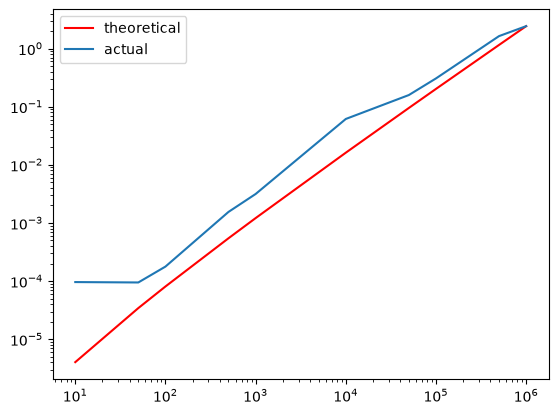

In [30]:
Analyse_Plot(sizes,theory,actual) # analyse plot